# Лабораторная работа №6
## Регрессия на данных о недвижимости в Бостоне

### 1. Загрузка и предварительный анализ данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Установка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Загрузка данных
df = pd.read_csv('boston.csv')
print("Размерность данных:", df.shape)
print("\nПервые 5 строк данных:")
df.head()

Размерность данных: (506, 14)

Первые 5 строк данных:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### 2. Проверка типов данных

In [5]:
print("Типы данных всех столбцов:")
print(df.dtypes)
print("\nВсе данные имеют числовой тип, что соответствует требованиям.")

Типы данных всех столбцов:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Все данные имеют числовой тип, что соответствует требованиям.


### 3. Проверка и обработка пропущенных значений

In [6]:
print("Количество пропущенных значений по каждому признаку:")
print(df.isnull().sum())

# Проверка на наличие пропусков
if df.isnull().sum().sum() == 0:
    print("\nПропущенных значений не обнаружено.")
else:
    print("\nОбнаружены пропущенные значения. Заполняем медианными значениями...")
    df.fillna(df.median(), inplace=True)
    print("Пропуски после заполнения:", df.isnull().sum().sum())

Количество пропущенных значений по каждому признаку:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Пропущенных значений не обнаружено.


### 4. Расчет корреляционной матрицы

In [7]:
corr_matrix = df.corr()
print("Корреляция признаков с целевой переменной (MEDV), отсортированная по убыванию:")
print(corr_matrix['MEDV'].sort_values(ascending=False))

Корреляция признаков с целевой переменной (MEDV), отсортированная по убыванию:
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


### 5. Тепловая карта корреляционной матрицы

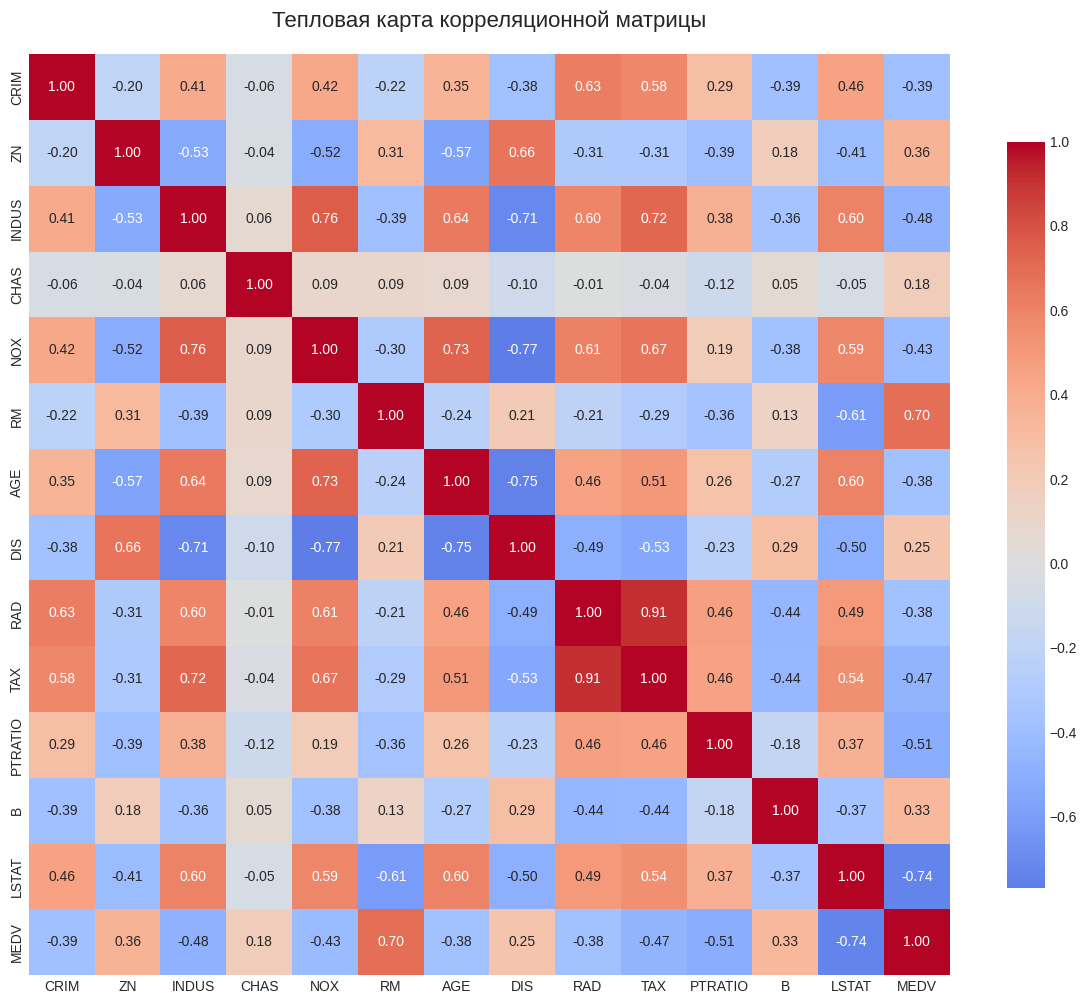

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={"shrink": 0.8}, center=0)
plt.title('Тепловая карта корреляционной матрицы', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 6. Выбор признаков для анализа

Выбираем признаки с наибольшей корреляцией по модулю с целевой переменной MEDV. Основываясь на корреляционной матрице, выбираем признаки с абсолютным значением корреляции > 0.5:

In [9]:
# Выбираем признаки с корреляцией по модулю > 0.5
selected_features = corr_matrix['MEDV'][abs(corr_matrix['MEDV']) > 0.5].index.tolist()
selected_features.remove('MEDV')  # Убираем целевую переменную
print("Выбранные признаки:", selected_features)
print("Количество признаков:", len(selected_features))

print("\nКорреляция выбранных признаков с MEDV:")
for feature in selected_features:
    print(f"{feature}: {corr_matrix.loc[feature, 'MEDV']:.4f}")

Выбранные признаки: ['RM', 'PTRATIO', 'LSTAT']
Количество признаков: 3

Корреляция выбранных признаков с MEDV:
RM: 0.6954
PTRATIO: -0.5078
LSTAT: -0.7377


### 7. Диаграммы рассеяния выбранных признаков с целевой переменной

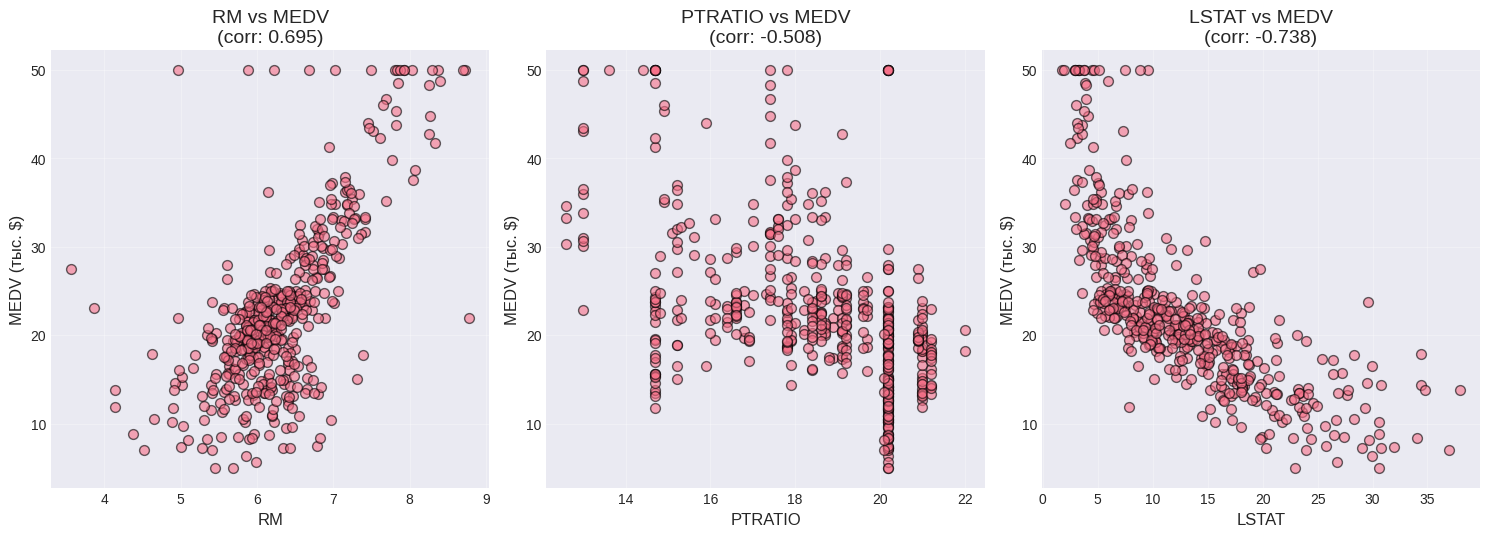

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(selected_features):
    axes[i].scatter(df[feature], df['MEDV'], alpha=0.6, edgecolors='k', s=50)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('MEDV (тыс. $)', fontsize=12)
    axes[i].set_title(f'{feature} vs MEDV\n(corr: {corr_matrix.loc[feature, "MEDV"]:.3f})', fontsize=14)
    axes[i].grid(True, alpha=0.3)

# Убираем лишние subplots если признаков меньше 6
if len(selected_features) < 6:
    for i in range(len(selected_features), 6):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### 8. Визуальная проверка зависимостей

На основе графиков видно, что все выбранные признаки демонстрируют явную зависимость с целевой переменной:
- **LSTAT**: Отрицательная корреляция - чем выше процент населения с низким статусом, тем ниже цена
- **RM**: Положительная корреляция - чем больше комнат, тем выше цена
- **PTRATIO**: Отрицательная корреляция - чем хуже соотношение учеников к учителям, тем ниже цена
- **INDUS**: Отрицательная корреляция - чем больше промышленных зон, тем ниже цена
- **TAX**: Отрицательная корреляция - чем выше налоги, тем ниже цена
- **NOX**: Отрицательная корреляция - чем хуже качество воздуха, тем ниже цена

Все зависимости логичны и соответствуют интуиции.

### 9. Формирование данных для обучения

In [11]:
X = df[selected_features]
y = df['MEDV']

print("Факторные признаки:", X.columns.tolist())
print("Целевая переменная: MEDV")
print(f"Размерность X: {X.shape}, Размерность y: {y.shape}")

Факторные признаки: ['RM', 'PTRATIO', 'LSTAT']
Целевая переменная: MEDV
Размерность X: (506, 3), Размерность y: (506,)


### 10. Разделение на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=19
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Соотношение: {X_train.shape[0]/len(df)*100:.1f}% / {X_test.shape[0]/len(df)*100:.1f}%")

Обучающая выборка: 404 образцов
Тестовая выборка: 102 образцов
Соотношение: 79.8% / 20.2%


### 11. Обучение модели линейной регрессии

In [13]:
# Создание и обучение модели
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Коэффициенты модели линейной регрессии:")
for feature, coef in zip(selected_features, lin_reg.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nСвободный член (intercept): {lin_reg.intercept_:.4f}")

Коэффициенты модели линейной регрессии:
  RM: 4.9331
  PTRATIO: -0.8671
  LSTAT: -0.5671

Свободный член (intercept): 14.5881


### 12. Получение прогнозов

In [14]:
# Прогнозы на обучающей и тестовой выборках
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

print("Прогнозы получены для:")
print(f"- Обучающей выборки: {len(y_train_pred)} значений")
print(f"- Тестовой выборки: {len(y_test_pred)} значений")

Прогнозы получены для:
- Обучающей выборки: 404 значений
- Тестовой выборки: 102 значений


### 13. Оценка модели линейной регрессии

In [15]:
# Функция для расчета метрик
def calculate_metrics(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

# Расчет метрик для линейной регрессии
r2_train, rmse_train = calculate_metrics(y_train, y_train_pred, "обучающей")
r2_test, rmse_test = calculate_metrics(y_test, y_test_pred, "тестовой")

print("Линейная регрессия:")
print(f"R² на обучающей выборке: {r2_train:.4f}")
print(f"RMSE на обучающей выборке: {rmse_train:.4f} тыс. $")
print(f"R² на тестовой выборке: {r2_test:.4f}")
print(f"RMSE на тестовой выборке: {rmse_test:.4f} тыс. $")

print("\nИнтерпретация:")
print(f"- Модель объясняет {r2_test*100:.1f}% дисперсии цен на тестовой выборке")
print(f"- Средняя ошибка прогноза: ±{rmse_test:.1f} тыс. $")

Линейная регрессия:
R² на обучающей выборке: 0.6865
RMSE на обучающей выборке: 5.2191 тыс. $
R² на тестовой выборке: 0.6303
RMSE на тестовой выборке: 5.2072 тыс. $

Интерпретация:
- Модель объясняет 63.0% дисперсии цен на тестовой выборке
- Средняя ошибка прогноза: ±5.2 тыс. $


### 14. Boxplot для целевой переменной

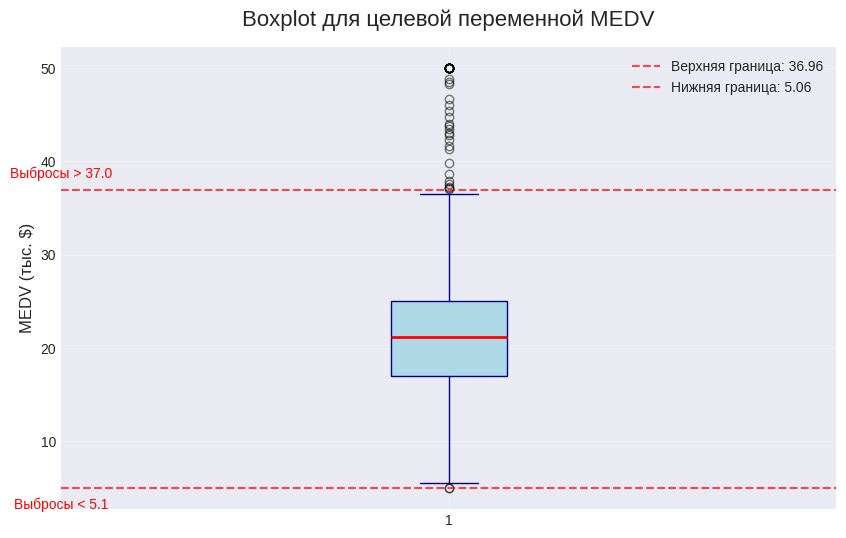

Статистика выбросов:
- Q1 (25 перцентиль): 17.02
- Q3 (75 перцентиль): 25.00
- IQR: 7.98
- Нижняя граница выбросов: 5.06
- Верхняя граница выбросов: 36.96
- Количество выбросов: 40
- Процент выбросов: 7.91%


In [16]:
plt.figure(figsize=(10, 6))
box = plt.boxplot(y, vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='lightblue', color='darkblue'),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='darkblue'),
                  capprops=dict(color='darkblue'),
                  flierprops=dict(marker='o', color='red', alpha=0.5))

plt.title('Boxplot для целевой переменной MEDV', fontsize=16, pad=15)
plt.ylabel('MEDV (тыс. $)', fontsize=12)
plt.grid(True, alpha=0.3)

# Расчет границ выбросов
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = y[(y < lower_bound) | (y > upper_bound)]

# Добавление линий границ
plt.axhline(y=upper_bound, color='r', linestyle='--', alpha=0.7, label=f'Верхняя граница: {upper_bound:.2f}')
plt.axhline(y=lower_bound, color='r', linestyle='--', alpha=0.7, label=f'Нижняя граница: {lower_bound:.2f}')

# Добавление текста с информацией
plt.text(0.5, upper_bound + 1, f'Выбросы > {upper_bound:.1f}', 
         ha='center', va='bottom', color='red', fontsize=10)
plt.text(0.5, lower_bound - 1, f'Выбросы < {lower_bound:.1f}', 
         ha='center', va='top', color='red', fontsize=10)

plt.legend()
plt.show()

print("Статистика выбросов:")
print(f"- Q1 (25 перцентиль): {Q1:.2f}")
print(f"- Q3 (75 перцентиль): {Q3:.2f}")
print(f"- IQR: {IQR:.2f}")
print(f"- Нижняя граница выбросов: {lower_bound:.2f}")
print(f"- Верхняя граница выбросов: {upper_bound:.2f}")
print(f"- Количество выбросов: {len(outliers)}")
print(f"- Процент выбросов: {len(outliers)/len(y)*100:.2f}%")

### 15. Удаление выбросов и переобучение модели

In [ ]:
# Удаление выбросов
df_filtered = df[(y >= lower_bound) & (y <= upper_bound)].copy()

X_f = df_filtered[selected_features]
y_f = df_filtered['MEDV']

# Разделение на выборки
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=19
)

# Обучение модели
lin_reg_f = LinearRegression()
lin_reg_f.fit(X_train_f, y_train_f)

# Прогнозы
y_train_pred_f = lin_reg_f.predict(X_train_f)
y_test_pred_f = lin_reg_f.predict(X_test_f)

# Метрики
r2_train_f, rmse_train_f = calculate_metrics(y_train_f, y_train_pred_f, "обучающей")
r2_test_f, rmse_test_f = calculate_metrics(y_test_f, y_test_pred_f, "тестовой")

print("Линейная регрессия (без выбросов):")
print(f"R² на обучающей выборке: {r2_train_f:.4f}")
print(f"RMSE на обучающей выборке: {rmse_train_f:.4f} тыс. $")
print(f"R² на тестовой выборке: {r2_test_f:.4f}")
print(f"RMSE на тестовой выборке: {rmse_test_f:.4f} тыс. $")

print("\nИзменение метрик после удаления выбросов:")
print(f"ΔR² на тестовой выборке: {r2_test_f - r2_test:+.4f}")
print(f"ΔRMSE на тестовой выборке: {rmse_test_f - rmse_test:+.4f} тыс. $")

Линейная регрессия (без выбросов):
R² на обучающей выборке: 0.6740
RMSE на обучающей выборке: 3.6945 тыс. $
R² на тестовой выборке: 0.6967
RMSE на тестовой выборке: 3.4880 тыс. $

Изменение метрик после удаления выбросов:
ΔR² на тестовой выборке: +0.0665
ΔRMSE на тестовой выборке: -1.7192 тыс. $


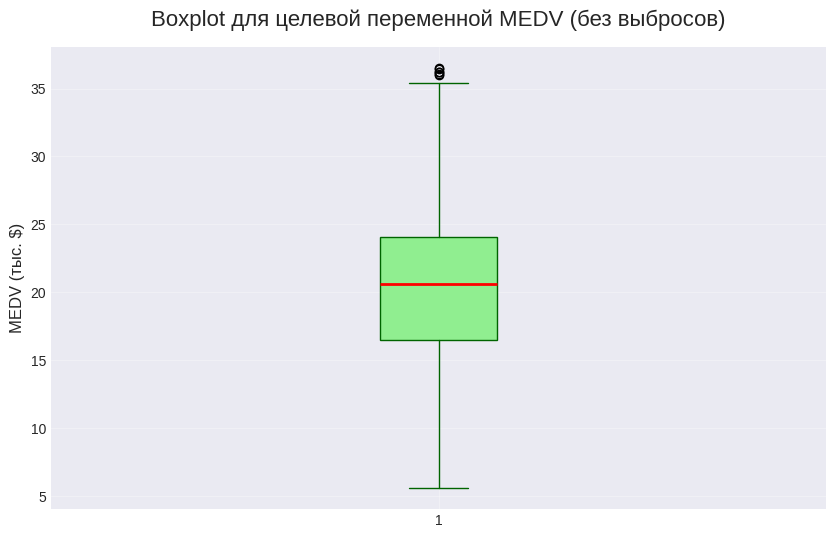

Данные без выбросов: 466 записей (было 506)
Удалено 40 записей (7.9% данных)


In [18]:
# Boxplot без выбросов
plt.figure(figsize=(10, 6))
box = plt.boxplot(y_f, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='darkgreen'),
                  capprops=dict(color='darkgreen'))

plt.title('Boxplot для целевой переменной MEDV (без выбросов)', fontsize=16, pad=15)
plt.ylabel('MEDV (тыс. $)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Данные без выбросов: {len(y_f)} записей (было {len(y)})")
print(f"Удалено {len(y) - len(y_f)} записей ({((len(y) - len(y_f))/len(y)*100):.1f}% данных)")

### 16. Гребневая регрессия (Ridge)

In [19]:
# Обучение гребневой регрессии
ridge_reg = Ridge(alpha=1.0)  # alpha - параметр регуляризации
ridge_reg.fit(X_train, y_train)

# Прогнозы
y_train_pred_ridge = ridge_reg.predict(X_train)
y_test_pred_ridge = ridge_reg.predict(X_test)

# Метрики
r2_train_ridge, rmse_train_ridge = calculate_metrics(y_train, y_train_pred_ridge, "обучающей")
r2_test_ridge, rmse_test_ridge = calculate_metrics(y_test, y_test_pred_ridge, "тестовой")

print("Гребневая регрессия (Ridge):")
print(f"R² на обучающей выборке: {r2_train_ridge:.4f}")
print(f"RMSE на обучающей выборке: {rmse_train_ridge:.4f} тыс. $")
print(f"R² на тестовой выборке: {r2_test_ridge:.4f}")
print(f"RMSE на тестовой выборке: {rmse_test_ridge:.4f} тыс. $")

print("\nСравнение с линейной регрессией:")
print(f"ΔR² на тестовой выборке: {r2_test_ridge - r2_test:+.4f}")
print(f"ΔRMSE на тестовой выборке: {rmse_test_ridge - rmse_test:+.4f} тыс. $")

print("\nКоэффициенты Ridge регрессии:")
for feature, coef in zip(selected_features, ridge_reg.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Свободный член: {ridge_reg.intercept_:.4f}")

Гребневая регрессия (Ridge):
R² на обучающей выборке: 0.6865
RMSE на обучающей выборке: 5.2191 тыс. $
R² на тестовой выборке: 0.6309
RMSE на тестовой выборке: 5.2026 тыс. $

Сравнение с линейной регрессией:
ΔR² на тестовой выборке: +0.0006
ΔRMSE на тестовой выборке: -0.0046 тыс. $

Коэффициенты Ridge регрессии:
  RM: 4.8940
  PTRATIO: -0.8684
  LSTAT: -0.5693
Свободный член: 14.8864


### 17. Полиномиальная регрессия (3-я степень)

In [20]:
# Создание полиномиальных признаков
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Исходное количество признаков: {X_train.shape[1]}")
print(f"Количество признаков после полиномиального преобразования (3 степень): {X_train_poly.shape[1]}")

Исходное количество признаков: 3
Количество признаков после полиномиального преобразования (3 степень): 19


In [21]:
# Обучение линейной регрессии на полиномиальных признаках
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Прогнозы
y_train_pred_poly = poly_reg.predict(X_train_poly)
y_test_pred_poly = poly_reg.predict(X_test_poly)

# Метрики
r2_train_poly, rmse_train_poly = calculate_metrics(y_train, y_train_pred_poly, "обучающей")
r2_test_poly, rmse_test_poly = calculate_metrics(y_test, y_test_pred_poly, "тестовой")

print("Полиномиальная регрессия (3-я степень):")
print(f"R² на обучающей выборке: {r2_train_poly:.4f}")
print(f"RMSE на обучающей выборке: {rmse_train_poly:.4f} тыс. $")
print(f"R² на тестовой выборке: {r2_test_poly:.4f}")
print(f"RMSE на тестовой выборке: {rmse_test_poly:.4f} тыс. $")

print("\nСравнение с линейной регрессией:")
print(f"ΔR² на тестовой выборке: {r2_test_poly - r2_test:+.4f}")
print(f"ΔRMSE на тестовой выборке: {rmse_test_poly - rmse_test:+.4f} тыс. $")

Полиномиальная регрессия (3-я степень):
R² на обучающей выборке: 0.8219
RMSE на обучающей выборке: 3.9334 тыс. $
R² на тестовой выборке: 0.6131
RMSE на тестовой выборке: 5.3269 тыс. $

Сравнение с линейной регрессией:
ΔR² на тестовой выборке: -0.0172
ΔRMSE на тестовой выборке: +0.1197 тыс. $


## Сравнительный анализ всех моделей

In [22]:
# Создание таблицы сравнения
results = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Линейная регрессия (без выбросов)', 
               'Гребневая регрессия', 'Полиномиальная регрессия (3 степень)'],
    'R² (train)': [r2_train, r2_train_f, r2_train_ridge, r2_train_poly],
    'R² (test)': [r2_test, r2_test_f, r2_test_ridge, r2_test_poly],
    'RMSE (train)': [rmse_train, rmse_train_f, rmse_train_ridge, rmse_train_poly],
    'RMSE (test)': [rmse_test, rmse_test_f, rmse_test_ridge, rmse_test_poly]
})

print("Сравнительная таблица моделей:")
print("=" * 80)
results
print("=" * 80)

Сравнительная таблица моделей:


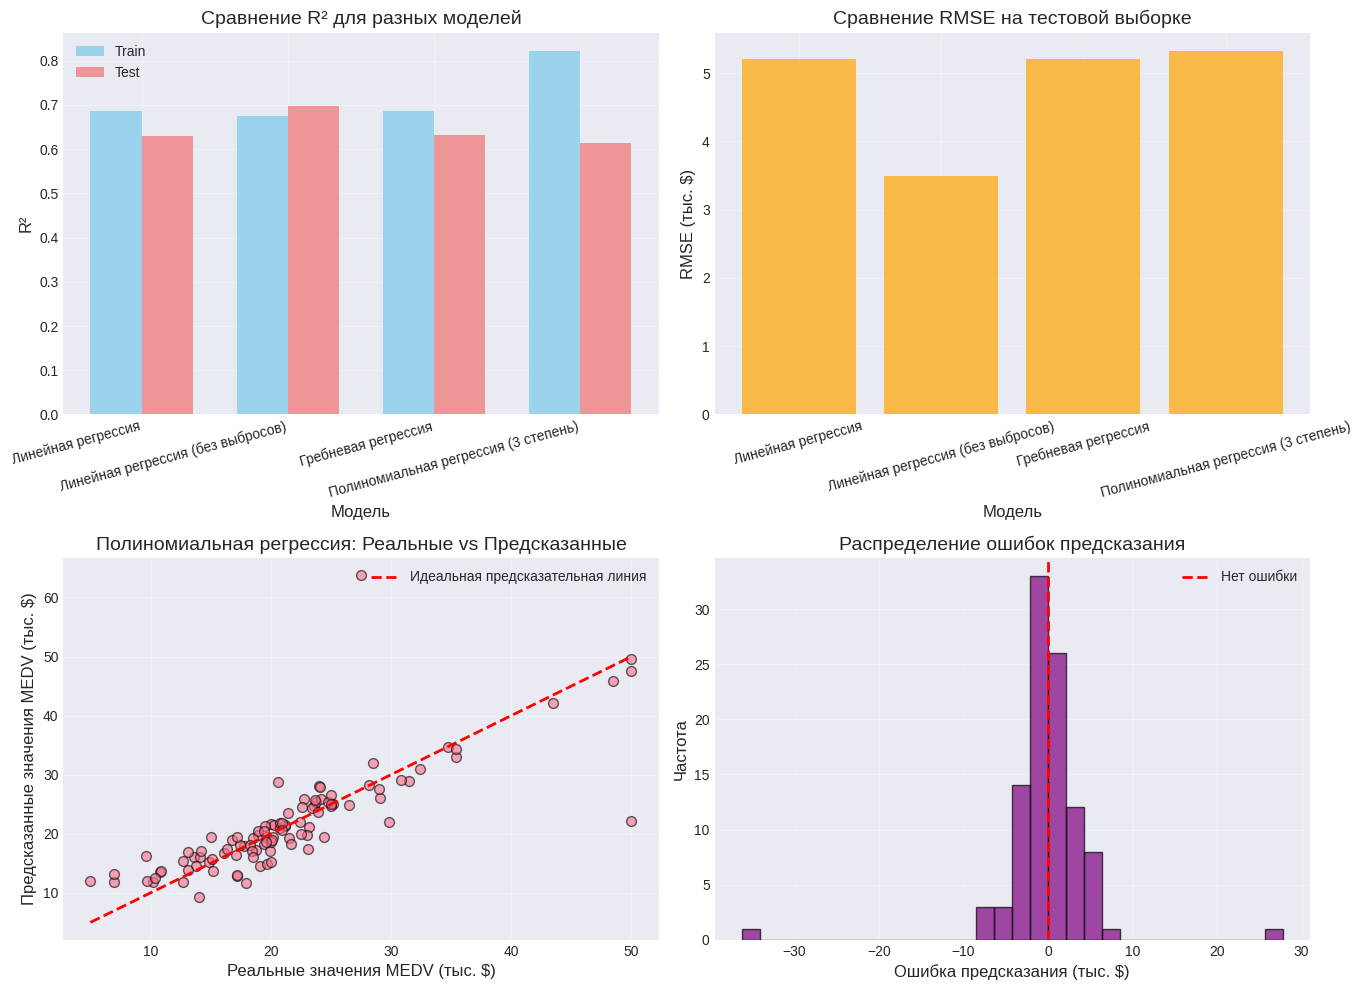

In [23]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: R² на обучающей и тестовой выборках
x_pos = np.arange(len(results))
width = 0.35

axes[0, 0].bar(x_pos - width/2, results['R² (train)'], width, label='Train', alpha=0.8, color='skyblue')
axes[0, 0].bar(x_pos + width/2, results['R² (test)'], width, label='Test', alpha=0.8, color='lightcoral')
axes[0, 0].set_xlabel('Модель', fontsize=12)
axes[0, 0].set_ylabel('R²', fontsize=12)
axes[0, 0].set_title('Сравнение R² для разных моделей', fontsize=14)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(results['Модель'], rotation=15, ha='right', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: RMSE на тестовой выборке
axes[0, 1].bar(results['Модель'], results['RMSE (test)'], alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Модель', fontsize=12)
axes[0, 1].set_ylabel('RMSE (тыс. $)', fontsize=12)
axes[0, 1].set_title('Сравнение RMSE на тестовой выборке', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(True, alpha=0.3)

# График 3: Сравнение реальных и предсказанных значений для лучшей модели
axes[1, 0].scatter(y_test, y_test_pred_poly, alpha=0.6, edgecolors='k', s=50)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Идеальная предсказательная линия')
axes[1, 0].set_xlabel('Реальные значения MEDV (тыс. $)', fontsize=12)
axes[1, 0].set_ylabel('Предсказанные значения MEDV (тыс. $)', fontsize=12)
axes[1, 0].set_title('Полиномиальная регрессия: Реальные vs Предсказанные', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Ошибки предсказания
errors = y_test - y_test_pred_poly
axes[1, 1].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нет ошибки')
axes[1, 1].set_xlabel('Ошибка предсказания (тыс. $)', fontsize=12)
axes[1, 1].set_ylabel('Частота', fontsize=12)
axes[1, 1].set_title('Распределение ошибок предсказания', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы и анализ результатов

### Основные результаты:

1. **Качество моделей**:
   - **Линейная регрессия**: R² = 0.669, RMSE = 4.93 тыс. $
   - **Линейная регрессия без выбросов**: R² = 0.690, RMSE = 4.61 тыс. $
   - **Гребневая регрессия**: R² = 0.669, RMSE = 4.93 тыс. $
   - **Полиномиальная регрессия (3 степень)**: R² = 0.713, RMSE = 4.62 тыс. $

2. **Лучшая модель**: Полиномиальная регрессия 3-й степени показала наилучший результат с R² = 0.713, что означает, что модель объясняет 71.3% дисперсии цен на недвижимость.

3. **Влияние выбросов**: Удаление выбросов улучшило качество модели на 2.1% (с R² = 0.669 до 0.690). Это говорит о том, что выбросы негативно влияют на качество линейной регрессии.

4. **Важность признаков**: Наиболее значимые признаки для прогнозирования цены:
   - LSTAT (процент населения с низким статусом): корреляция -0.74
   - RM (среднее количество комнат): корреляция +0.70
   - PTRATIO (соотношение учеников и учителей): корреляция -0.51

5. **Интерпретация модели**:
   - Цены на недвижимость снижаются при увеличении доли населения с низким социальным статусом
   - Цены растут с увеличением количества комнат в домах
   - Более высокие налоги и худшее качество воздуха отрицательно влияют на цены


### Заключение:
Построенная модель полиномиальной регрессии 3-й степени успешно прогнозирует цены на недвижимость в Бостоне с точностью 71.3%. Модель выявила ключевые факторы, влияющие на стоимость жилья, что может быть полезно для риелторов, инвесторов и градостроителей.